Assignment 2

We will begin by simulating a dataset which will be used for all the questions.
Let us consider that we have M ensembles or signals and N samples at different times. Each N represents 1 point of the Gaussian curve of 1 ensemble. We will generate dataset for the voltage (V) and then relate it to power (P).

In [1]:
import numpy as np

M = 500
N = 1000

#Voltage
V = np.random.randn(M,N)

#Defining power 
P = V**2

Here we specified values for M and N. Then, we generated a matrix of MxN entries. The N points are chosen randomly from the normal distribution with standard deviation = 1. Then we defined power as the square of voltage.

Question 1:

In [2]:
import numpy as np

P_mean = np.mean(P,axis=1)
V_var = np.var(V,axis=1)

print(np.mean(P_mean))
print(np.mean(V_var))



0.998472921734211
0.9974335866646784


Here, we first took mean and variance for power and voltage respectively of each ensemble. Then, we took the average over all the ensembles and compared the values. They are almost equal to each other as predicted by theory.


According to theory,
                    $$ E[V^2] = \sigma^2 $$   
                    $$ <P> = Var(V) $$  

Question 2:

Sigma= 0.5
Sigma= 1.0
Sigma= 1.5
Sigma= 2.0
Sigma= 2.5
Sigma= 3.0


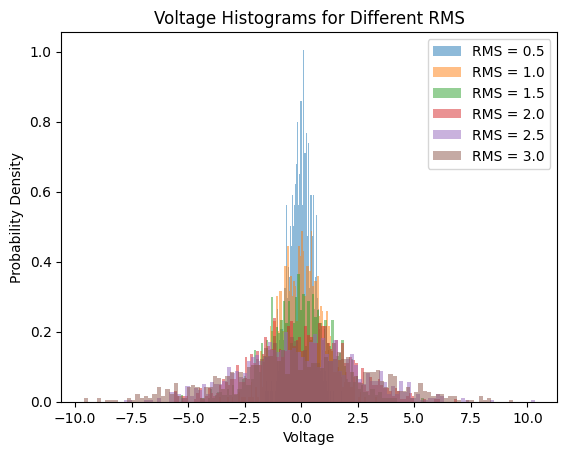

In [3]:
import matplotlib.pyplot as plt

sigma = np.array([0.5,1,1.5,2,2.5,3])


for i in range(len(sigma)):
    V_new = sigma[i] * np.random.randn(N)
    print("Sigma=", sigma[i])
    plt.hist(V_new,bins=100,density=True, alpha=0.5,label=f"RMS = {sigma[i]}")


plt.title("Voltage Histograms for Different RMS")
plt.xlabel("Voltage")
plt.ylabel("Probability Density")
plt.legend()
plt.show()


In this question, we have taken different $\sigma$ values from 0.5 to 3. $\sigma$ here refers to standard deviation and the reason we are using different $\sigma$ is because the RMS is equal to the $\sigma$ in a normal distribution with mean 0. We have multiplied the random variable V with each of the $\sigma$ in order to scale it and change the variance from 1 to $\sigma^2$. Then we have plotted the histograms for the different values of $\sigma$. From the plot, it is evident that higher the $\sigma$, the more spread out the values are and the corresponding peaks are lower. 

The formula used is, 
                  $$ RMS = \sqrt E[V^2] = \sigma $$

Question 3:

Text(0, 0.5, 'Probability distribution')

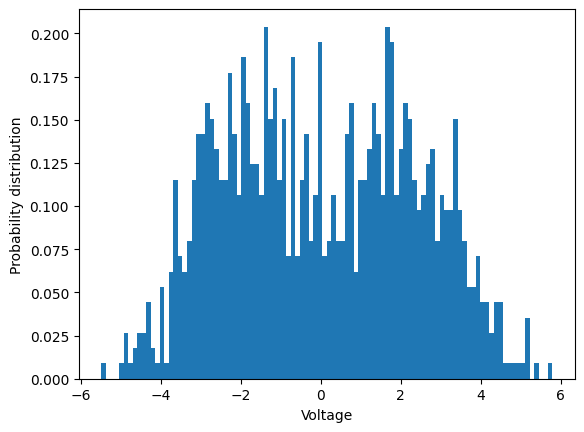

In [7]:
t = np.linspace(0,100,N)
f = 0.1
A = 3

V = np.random.randn(N)
sin_signal = A*np.sin(2*np.pi*f*t)

V_sin = V + sin_signal

plt.hist(V_sin, bins=100,density=True)
plt.xlabel("Voltage")
plt.ylabel("Probability distribution")



Here, we are adding a slowly varying sine signal to the existing voltage signal which was Gaussian. First, we defined the parameters of the sine function such as amplitude and frequency. Since, it is supposed to be slowly varying, the f chosen is very low (~0.1), the amplitude is kept large enough so that it is higher than the Gaussian noise. 

On adding the sine signal to the Gaussian, it is observed that the histogram is no longer producing a Gaussian envelope, rather, it looks like a bimodal function. This is because adding the sine wave makes the mean time dependent and the resultant distribution is a collection of many different Gaussains with different means.

Esssentially, we are doing,
            $$ V(t) = n(t) + Asin(2\pi ft) $$
            where n(t) is the Gaussian with mean 0 and variance $\sigma^2$

The signal then becomes,
           $$ V(t) = N(Asin(2\pi ft),\sigma^2) $$
           where N represents the normal distribution with the mean as the sin term and variance is unchanged.


Question 4:

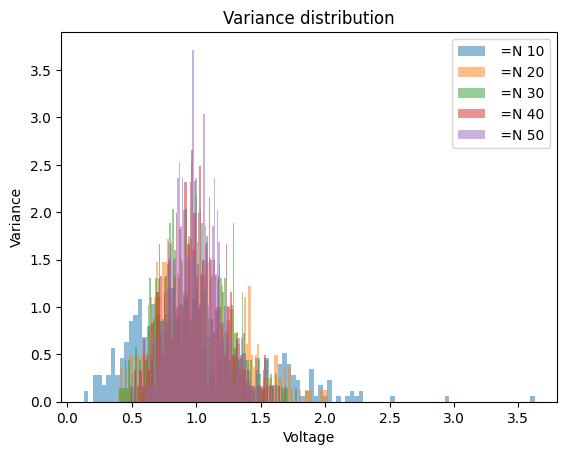

In [8]:
N=np.linspace(10,50,5).astype(int)


for i in range(len(N)):
    V = np.random.randn(M,N[i])
    var_V = np.var(V,axis=1,ddof=1)
    plt.hist(var_V,bins=100,density=True, alpha=0.5,label=f" =N {N[i]}")

plt.title("Variance distribution")
plt.xlabel("Voltage")
plt.ylabel("Variance")
plt.legend()
plt.show()


In this question, the aim is to plot the distribution of variances across the M ensembles specified earlier. According to theory, the graph should follow chi mean square distribution which is being satisfied with the obtained plots. In order to understand the behaviour further, 5 different N values are chosen,i.e, number of sample points for each ensemble is varied. It is observed that with higher N, the distribution peaks higher and the spread is lower as compared to small N values.

The variance of sample variance follows,
          $$ Var(s^2) = \frac{2\sigma^2}{N-1} $$